In [5]:
# Most of this code is taken from the research module code 

In [6]:
%matplotlib inline

In [7]:
# Imports
import os

SALVUS_FLOW_SITE_NAME = os.environ.get("salome_remote") # Site name given in the installation of Salvus flow
PROJECT_DIR = "simulation_wavefield_output"  

# Add code to keep .gitignore updated to ignore salvus files
gitignore_path = ".gitignore"
with open(gitignore_path, "r+") as f:
    contents = f.read()
    if PROJECT_DIR not in contents:
        f.write(f"\n{PROJECT_DIR}/\n")

import pathlib
import numpy as np
import salvus.namespace as sn
import xarray as xr
import salvus.namespace as sn
from salvus.project.tools.processing import block_processing
from salvus.toolbox.helpers.wavefield_output import (
    WavefieldOutput,
    wavefield_output_to_xarray,
)
import matplotlib.pyplot as plt
from matplotlib import animation
import obspy

# For wavefield output code
from salvus.mesh.unstructured_mesh_utils import read_model_from_h5
from salvus.toolbox.helpers import wavefield_output

#for plotting of wiggles, traces 
from scipy import signal

In [8]:
# # Delete entire project directory to clear all cached metadata
# import shutil
# if pathlib.Path(PROJECT_DIR).exists():
#     shutil.rmtree(PROJECT_DIR)
#     print(f"Deleted {PROJECT_DIR}")

In [9]:
# Setup of the model domain as a box (same as research module)
domain_2d = sn.domain.dim2.BoxDomain(x0=0, x1=30, y0=0, y1=3)
p = sn.Project.from_domain(path=PROJECT_DIR, domain=domain_2d, load_if_exists=True)

Accordion()

In [10]:

# Layered model setup according to mondaic docs
# Minimal and maximal x extent: same as domain box
x_min = 0.0
x_max = 30

# Defining extent of löayers (layers_x) and thickness / topography of layers (layers_y)
layers_x = [
    np.array([0.0, 30.0]),  # top boundary
    np.array([0.0, 30.0]),  # snow-air interface
    np.array([0.0, 30.0]),  # earth-snow interface 
    np.array([0.0, 30.0]),  # bottom boundary
]

layers_y = [
    np.array([3.0, 3.0]),        
    np.array([3*2/3, 3*2/3]),        
    np.array([3*1/3, 3*1/3]),        
    np.array([0.0, 0.0]),        
]

# Defining model parameters (vp, vs and rho) for earth, snow and air, earth and air velocities taken from https://pburnley.faculty.unlv.edu/GEOL452_652/seismology/notes/SeismicNotes10RVel.html
vp = np.array([2200, 300, 332])
#vs = np.array([0,0,0])
vs = np.array([880, 150,0])
rho = np.array([2000, 180, 1.2250])


interpolation_styles = ["linear"] * len(layers_x)


splines = sn.toolbox.get_interpolating_splines(
    layers_x, layers_y, kind=interpolation_styles
)

# # Plotting the layer boundaries to check if they are correct
# f = plt.figure(figsize=(10, 5))
# x_plot = np.linspace(x_min, x_max)
# for top, bot in splines:
#     plt.plot(x_plot, top(x_plot))
#     plt.plot(x_plot, bot(x_plot))

# plt.xlabel("x (m)")
# plt.ylabel("y (m)")
# plt.title("Interfaces")
# plt.ylim(0,1.5)

# Genetarte mesh
# Maximum frequency to resolve with elements_per_wavelength.
max_frequency = 50.0

# Print lenght of splines because of size mismatch between splines and vs
shp = len(splines)
print(shp)

slowest_velocities = np.array([
    880,   # earth
    150,   # snow
    150,   # air layer meshing controlled by snow below --> need this because else slowest_velocities gives an errror because it goes to infinity
])

# Generate the mesh
mesh, bnd = sn.toolbox.generate_mesh_from_splines_2d(
    x_min=0,
    x_max=x_max,
    splines=splines,
    elements_per_wavelength=2,
    maximum_frequency=max_frequency,
    use_refinements=True,
    slowest_velocities=slowest_velocities,
    # make very bottom boundary, very top (in x) and both sides in y absorbing
    absorbing_boundaries=(["x0", "x1", "y0", "y1"], 10.0), # Change this if different boundaries need to be absorbing CHECK 
)

mesh = np.sum(mesh)

# Add info about absorbing boundaries CHANGE DEPENDING ON WHICH BOUNDARIES NEED TO BE TRANSPARENT / ABSORBING
mesh.attach_global_variable("max_dist_ABC", bnd)
mesh.attach_global_variable("ABC_side_sets", ", ".join(["x0", "x1", "y0"]))
mesh.attach_global_variable("ABC_vel", float(min(vs[vs > 0])))
mesh.attach_global_variable("ABC_freq", max_frequency / 2.0)
mesh.attach_global_variable("ABC_nwave", 5.0)


# Attaching parameters (vp,vs,rho) to mesh 
nodes = mesh.get_element_nodes()[:, :, 0]
vp_a, vs_a, ro_a = np.ones((3, *nodes.shape))
for _i, (vp_val, vs_val, ro_val) in enumerate(zip(vp, vs, rho)):
    # Find which elements are in a given region.
    idx = np.where(mesh.elemental_fields["region"] == _i)

    # Set parameters in that region to a constant value.
    vp_a[idx] = vp_val
    vs_a[idx] = vs_val
    ro_a[idx] = ro_val

# Attach parameters.
for k, v in zip(["VP", "VS", "RHO"], [vp_a, vs_a, ro_a]):
    mesh.attach_field(k, v)

# Attach acoustic / elastic flag.
mesh_2d_layered = sn.toolbox.detect_fluid(mesh)

# # Checking which values are assigned to which layer: LAYER 0 IS THE BOTTOM LAYER
# np.unique(mesh.elemental_fields["region"])
# for i in range(3):
#     idx = mesh.elemental_fields["region"] == i
#     print(i,
#           np.unique(mesh.elemental_fields["VP"][idx]),
#           np.unique(mesh.elemental_fields["VS"][idx]),
#           np.unique(mesh.elemental_fields["RHO"][idx]))


# # Plot Mesh toc heck
#mesh_2d_layered



3


In [11]:
# Soure located at the top of the domain 
src = sn.simple_config.source.cartesian.VectorPoint2D(
    # x=15.0,
    # y=2.5,
    # #radius_of_sphere_in_m=6371000.0,
    # myy=0,
    # mxx=0,
    # mxy=3e4,
    x=15,
    y=1.5,
    fx=0.0,
    fy=-1.0,
    #f=-1, 
) # fx and fy values dependend on the type and force of source

p.add_to_project(sn.Event(event_name="event_wavefield_output", sources=[src]))

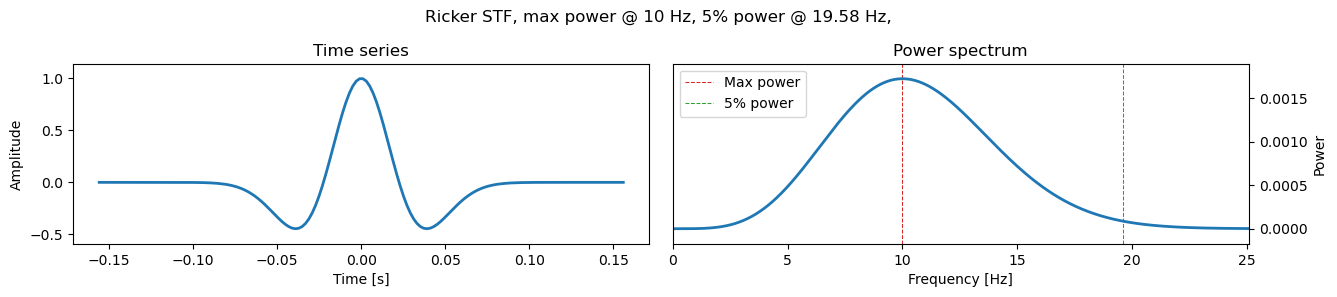

In [12]:
ec = sn.EventConfiguration(
    wavelet=sn.simple_config.stf.Ricker(center_frequency=10), # THE SAME AS IN EVENT CONFIGUARTEIN: needs to be at least v/(thickness*4)
    waveform_simulation_configuration=sn.WaveformSimulationConfiguration(
    
    ),
)
ec.wavelet.plot()

In [13]:
p.add_to_project(
    sn.UnstructuredMeshSimulationConfiguration(
        name="sim_2d_layered",
        unstructured_mesh=mesh_2d_layered,
        event_configuration=sn.EventConfiguration(
            wavelet=sn.simple_config.stf.Ricker(
                center_frequency=10,
                time_shift_in_seconds=0.3  # shifts wavelet 
            ),
            waveform_simulation_configuration=sn.WaveformSimulationConfiguration(
                start_time_in_seconds=-0.3,
                end_time_in_seconds=2.0,
            ),
        ),
    ),
)

In [14]:
# # For layered model 
# p.add_to_project(
#     sn.UnstructuredMeshSimulationConfiguration(
#         name="sim_2d_layered",
#         unstructured_mesh=mesh_2d_layered,
#         event_configuration=sn.EventConfiguration(
#         wavelet=sn.simple_config.stf.Ricker(center_frequency=10),
#         waveform_simulation_configuration=sn.WaveformSimulationConfiguration(
#             start_time_in_seconds=-0.3,
#             end_time_in_seconds=10.0, 
#             ),
#         ),
#     ),
# )
# #p.viz.nb.simulation_setup("sim_2d_layered", events=["event_wavefield_output"])

In [21]:
# # List all simulations and their statuses
# p.simulations.list()

# Layered
p.simulations.launch(
    simulation_configuration="sim_2d_layered",
    events=p.events.list(),
    site_name="salome_remote", 
    ranks_per_job=8,
    extra_output_configuration={
        "volume_data": {
            "sampling_interval_in_time_steps": 400,
            "fields": ["velocity", "displacement"], # add displacement to field 
        },
    },
)
p.simulations.query(block=True)

[2026-04-01 12:00:44,052] INFO: Data for 1 event(s) already exists. They will not be submitted again. The requested extra_output_configuration is fully contained in the existing results. If you really want to rerun the simulations, please delete the results first using p.simulations.delete_results().


VBox()

True

In [ ]:
# # Sublevel safe path for import of wavefield data
# import glob

# # Plotting wavefield output at one point in time
# out_2d_layered = p.simulations.get_simulation_output_directory("sim_2d_layered", "event_wavefield_output")

# # Memory-safe read: load every Nth stored time step instead of the full volume
# time_step_stride = 10

# # Dynamically find the volume_data_output.h5 file (path includes hash-based subdirs)
# import glob, os

# matches = glob.glob(str(out_2d_layered / "**" / "volume_data_output.h5"), recursive=True)
# for f in matches:
#     size_gb = os.path.getsize(f) / 1e9
#     print(f"{size_gb:.2f} GB  —  {f}")

# vel_wo_layered = wavefield_output.WavefieldOutput.from_file(
#     h5_path,
#     "velocity",
#     "volume",
#     time_steps=slice(0, None, time_step_stride),
# )

# # Converting to an xarray on a regular plotting grid
# vel_2d_layered = wavefield_output.wavefield_output_to_xarray(
#     vel_wo_layered,
#     points=[np.linspace(0, 30, 101), np.linspace(0, 3, 101)],
# )

# # Plotting wavefield output
# fig, ax = plt.subplots()
# plot_time_seconds = 0.8
# vel_2d_layered.sel(t=plot_time_seconds, method="nearest").isel(c=0).T.plot(
#     shading="gouraud",
#     infer_intervals=False,
# )
# ax.set_ylim(0, 3)
# ax.set_xlim(0, 30)
# ax.invert_yaxis()
# ax.set_ylabel("Depth (m)")
# ax.set_xlabel("Distance (m)")
# plt.show()

0.02 GB  —  simulation_wavefield_output/EVENTS/event_wavefield_output/WAVEFORM_DATA/INTERNAL/14/cf/0d5cb60266de/volume_data_output.h5


NameError: name 'h5_path' is not defined

Finding enclosing elements (pass 1 of auto):   0%|          | 0/10201 [00:00<?, ?it/s]

Finding enclosing elements (pass 2 of auto):   0%|          | 0/6868 [00:00<?, ?it/s]

Finding enclosing elements (pass 3 of auto):   0%|          | 0/6868 [00:00<?, ?it/s]

Finding enclosing elements (pass 4 of auto):   0%|          | 0/6868 [00:00<?, ?it/s]

Finding enclosing elements (pass 5 of auto):   0%|          | 0/3434 [00:00<?, ?it/s]

...

Finding enclosing elements (pass 7 of auto):   0%|          | 0/3434 [00:00<?, ?it/s]

Finding enclosing elements (pass 8 of auto):   0%|          | 0/3434 [00:00<?, ?it/s]

Finding enclosing elements (pass 9 of auto):   0%|          | 0/3434 [00:00<?, ?it/s]

[2026-04-01 12:11:19,407] WARNING - salvus.mesh.algorithms.unstructured_mesh.utils: 3434 points were not claimed by enclosing elements. Depending on your use case, this may not be an issue.


Extracting wavefield to regular grid:   0%|          | 0/19 [00:00<?, ?it/s]

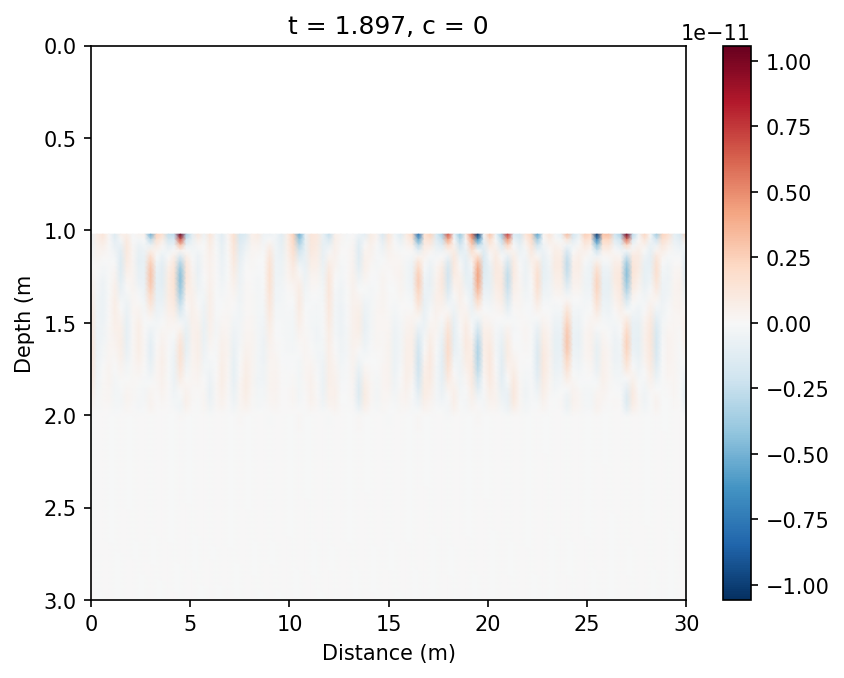

In [26]:
# Plotting wvaefield output at one point in time
out_2d_layered = p.simulations.get_simulation_output_directory("sim_2d_layered", "event_wavefield_output")

vel_wo_layered = wavefield_output.WavefieldOutput.from_file(
    pathlib.Path(
        out_2d_layered,
        "volume_data_output.h5",
    ),
    "velocity",
    "volume",
)

# Converting to an x array
vel_2d_layered = wavefield_output.wavefield_output_to_xarray(
    vel_wo_layered,
    points=[np.linspace(0, 30, 101), np.linspace(0, 3, 101)],
)

# Plotting wavefield output
# T is the timeslice (the t'th output image)
fig, ax = plt.subplots()
vel_2d_layered.isel(c=0, t=56).T.plot(shading="gouraud", infer_intervals=False)
ax.set_ylim(0,3)
ax.set_xlim(0,30)
ax.invert_yaxis()
ax.set_ylabel("Depth (m")
ax.set_xlabel("Distance (m)")
plt.show()


 


In [20]:
plt.rcParams["animation.html"] = "jshtml"
plt.rcParams["figure.dpi"] = 150
plt.rcParams["animation.embed_limit"] = 100
plt.ioff()

# Getting wavefield output like above (memory-safe decimation in time)
out_2d_layered = p.simulations.get_simulation_output_directory(
    "sim_2d_layered", "event_wavefield_output"
)

time_step_stride = 100
vel_wo_layered = wavefield_output.WavefieldOutput.from_file(
    pathlib.Path(out_2d_layered, "volume_data_output.h5"),
    "velocity",
    "volume",
    time_steps=slice(0, None, time_step_stride),
)
vel_2d_layered = wavefield_output.wavefield_output_to_xarray(
    vel_wo_layered,
    points=[
        np.linspace(0, 30, 101),  # width (m)
        np.linspace(0, 3, 101),   # height (m)
    ],
)

# Setting up animation
fig, ax = plt.subplots()

def animate(t):
    for coll in ax.collections:
        coll.remove()

    vel_2d_layered.isel(c=1, t=t).T.plot(
        ax=ax,
        shading="gouraud",
        infer_intervals=False,
        add_colorbar=False,
    )

    # Force axis limits
    ax.set_ylim(0,3)
    ax.set_xlim(0,30)
    ax.invert_yaxis()
    ax.set_ylabel("Depth (m)")
    ax.set_xlabel("Distance (m)")

    # Kill autoscaling
    ax.set_autoscale_on(False)

    ax.set_title(f"Velocity field (t = {t})")

# Creating animation
ani_layered = animation.FuncAnimation(
    fig,
    animate,
    frames=vel_2d_layered.sizes["t"],
    interval=100  # change interval to a higher value for slower animation
)

ani_layered

Finding enclosing elements (pass 1 of auto):   0%|          | 0/10201 [00:00<?, ?it/s]

Finding enclosing elements (pass 2 of auto):   0%|          | 0/6868 [00:00<?, ?it/s]

Finding enclosing elements (pass 3 of auto):   0%|          | 0/6868 [00:00<?, ?it/s]

Finding enclosing elements (pass 4 of auto):   0%|          | 0/6868 [00:00<?, ?it/s]

Finding enclosing elements (pass 5 of auto):   0%|          | 0/3434 [00:00<?, ?it/s]

...

Finding enclosing elements (pass 7 of auto):   0%|          | 0/3434 [00:00<?, ?it/s]

Finding enclosing elements (pass 8 of auto):   0%|          | 0/3434 [00:00<?, ?it/s]

Finding enclosing elements (pass 9 of auto):   0%|          | 0/3434 [00:00<?, ?it/s]

[2026-04-01 11:59:03,022] WARNING - salvus.mesh.algorithms.unstructured_mesh.utils: 3434 points were not claimed by enclosing elements. Depending on your use case, this may not be an issue.


Extracting wavefield to regular grid:   0%|          | 0/19 [00:00<?, ?it/s]

Finding enclosing elements (pass 1 of auto):   0%|          | 0/1001 [00:00<?, ?it/s]

Extracting wavefield to regular grid:   0%|          | 0/4 [00:00<?, ?it/s]

Finding enclosing elements (pass 1 of auto):   0%|          | 0/1001 [00:00<?, ?it/s]

Extracting wavefield to regular grid:   0%|          | 0/4 [00:00<?, ?it/s]

vel_sg dims: ('t', 'c', 'point')
vel_sg shape: (60, 2, 1001)
t range: -0.3 → 2.0152058008104072
t values (first 10): [-0.3        -0.26075922 -0.22151845 -0.18227767 -0.14303689 -0.10379612
 -0.06455534 -0.02531457  0.01392621  0.05316699]
sg_vy shape after t-slice: (51, 1001)
sg_vy size: 51051


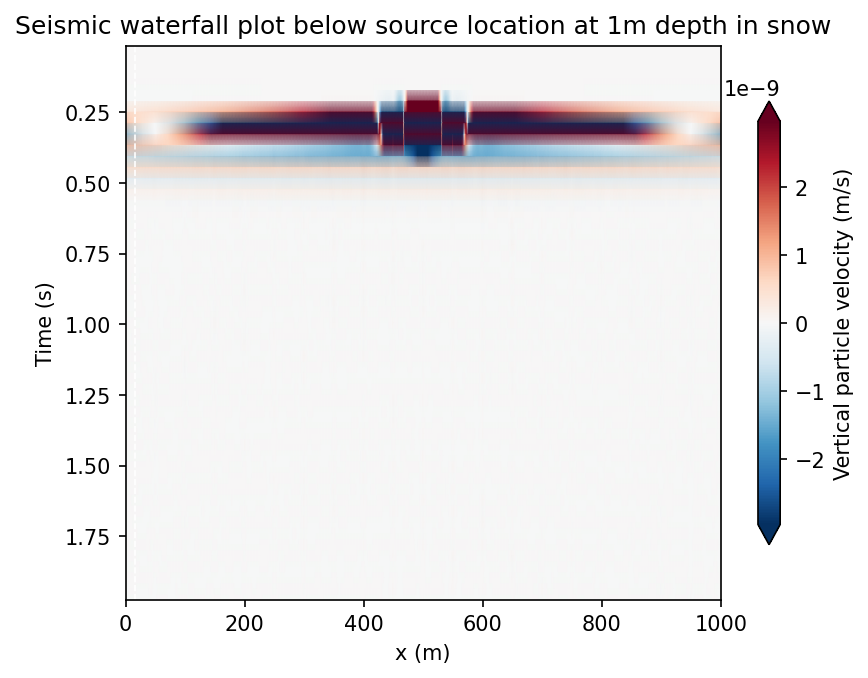

In [27]:
y_surface = 3 * 1 / 3
x_line = np.linspace(0.0, 30.0, 1001)
y_line = np.full_like(x_line, y_surface)
vel_sg = wavefield_output.wavefield_output_to_xarray(
    vel_wo_layered,  # already strided at every 100th step
    points=np.column_stack((x_line, y_line)),
)
# vy is vertical particle velocity — most sensitive to P-wave arrivals
sg_vy = vel_sg.isel(c=1).sel(t=slice(0, 2.0))
sg_vy["point"] = x_line  # distance in m along x

vel_sg = wavefield_output.wavefield_output_to_xarray(
    vel_wo_layered,
    points=np.column_stack((x_line, y_line)),
)

print("vel_sg dims:", vel_sg.dims)
print("vel_sg shape:", vel_sg.shape)
print("t range:", float(vel_sg.t.min()), "→", float(vel_sg.t.max()))
print("t values (first 10):", vel_sg.t.values[:10])

sg_vy = vel_sg.isel(c=1).sel(t=slice(0, 2.0))
print("sg_vy shape after t-slice:", sg_vy.shape)
print("sg_vy size:", sg_vy.size)

sg_vy.plot(
    x="point",
    y="t",
    shading="gouraud",
    infer_intervals=False,
    cbar_kwargs={"label": "Vertical particle velocity (m/s)", "shrink": 0.8},
    yincrease=False,
    robust=True,  # clips colorscale so source doesn't dominate
)
plt.xlabel("x (m)")
plt.ylabel("Time (s)")
plt.axvline(x=15, color="white", lw=0.8, linestyle="--", label="source x=15")
plt.title("Seismic waterfall plot below source location at 1m depth in snow")
plt.show()

In [ ]:
# dt         = float(vel_sg.t.diff("t").mean())
# start_time = float(vel_sg.t.min())
# end_time   = float(vel_sg.t.max())
# fs         = 1.0 / dt
# n_samples  = vel_sg.sizes["t"]

# print(f"start_time: {start_time:.6f} s")
# print(f"end_time:   {end_time:.6f} s")
# print(f"dt:         {dt:.8f} s")
# print(f"fs:         {fs:.2f} Hz")
# print(f"Nyquist:    {fs/2:.2f} Hz")
# print(f"n_samples:  {n_samples}")

# # check if wavelet is properly contained
# f0 = 10.0
# t_needed = -2.0 / f0   # = -0.2 s minimum start time
# print(f"\nWavelet needs start_time <= {t_needed:.3f} s")
# print(f"Your start_time is {start_time:.3f} s")
# print(f"Wavelet contained: {start_time <= t_needed}")

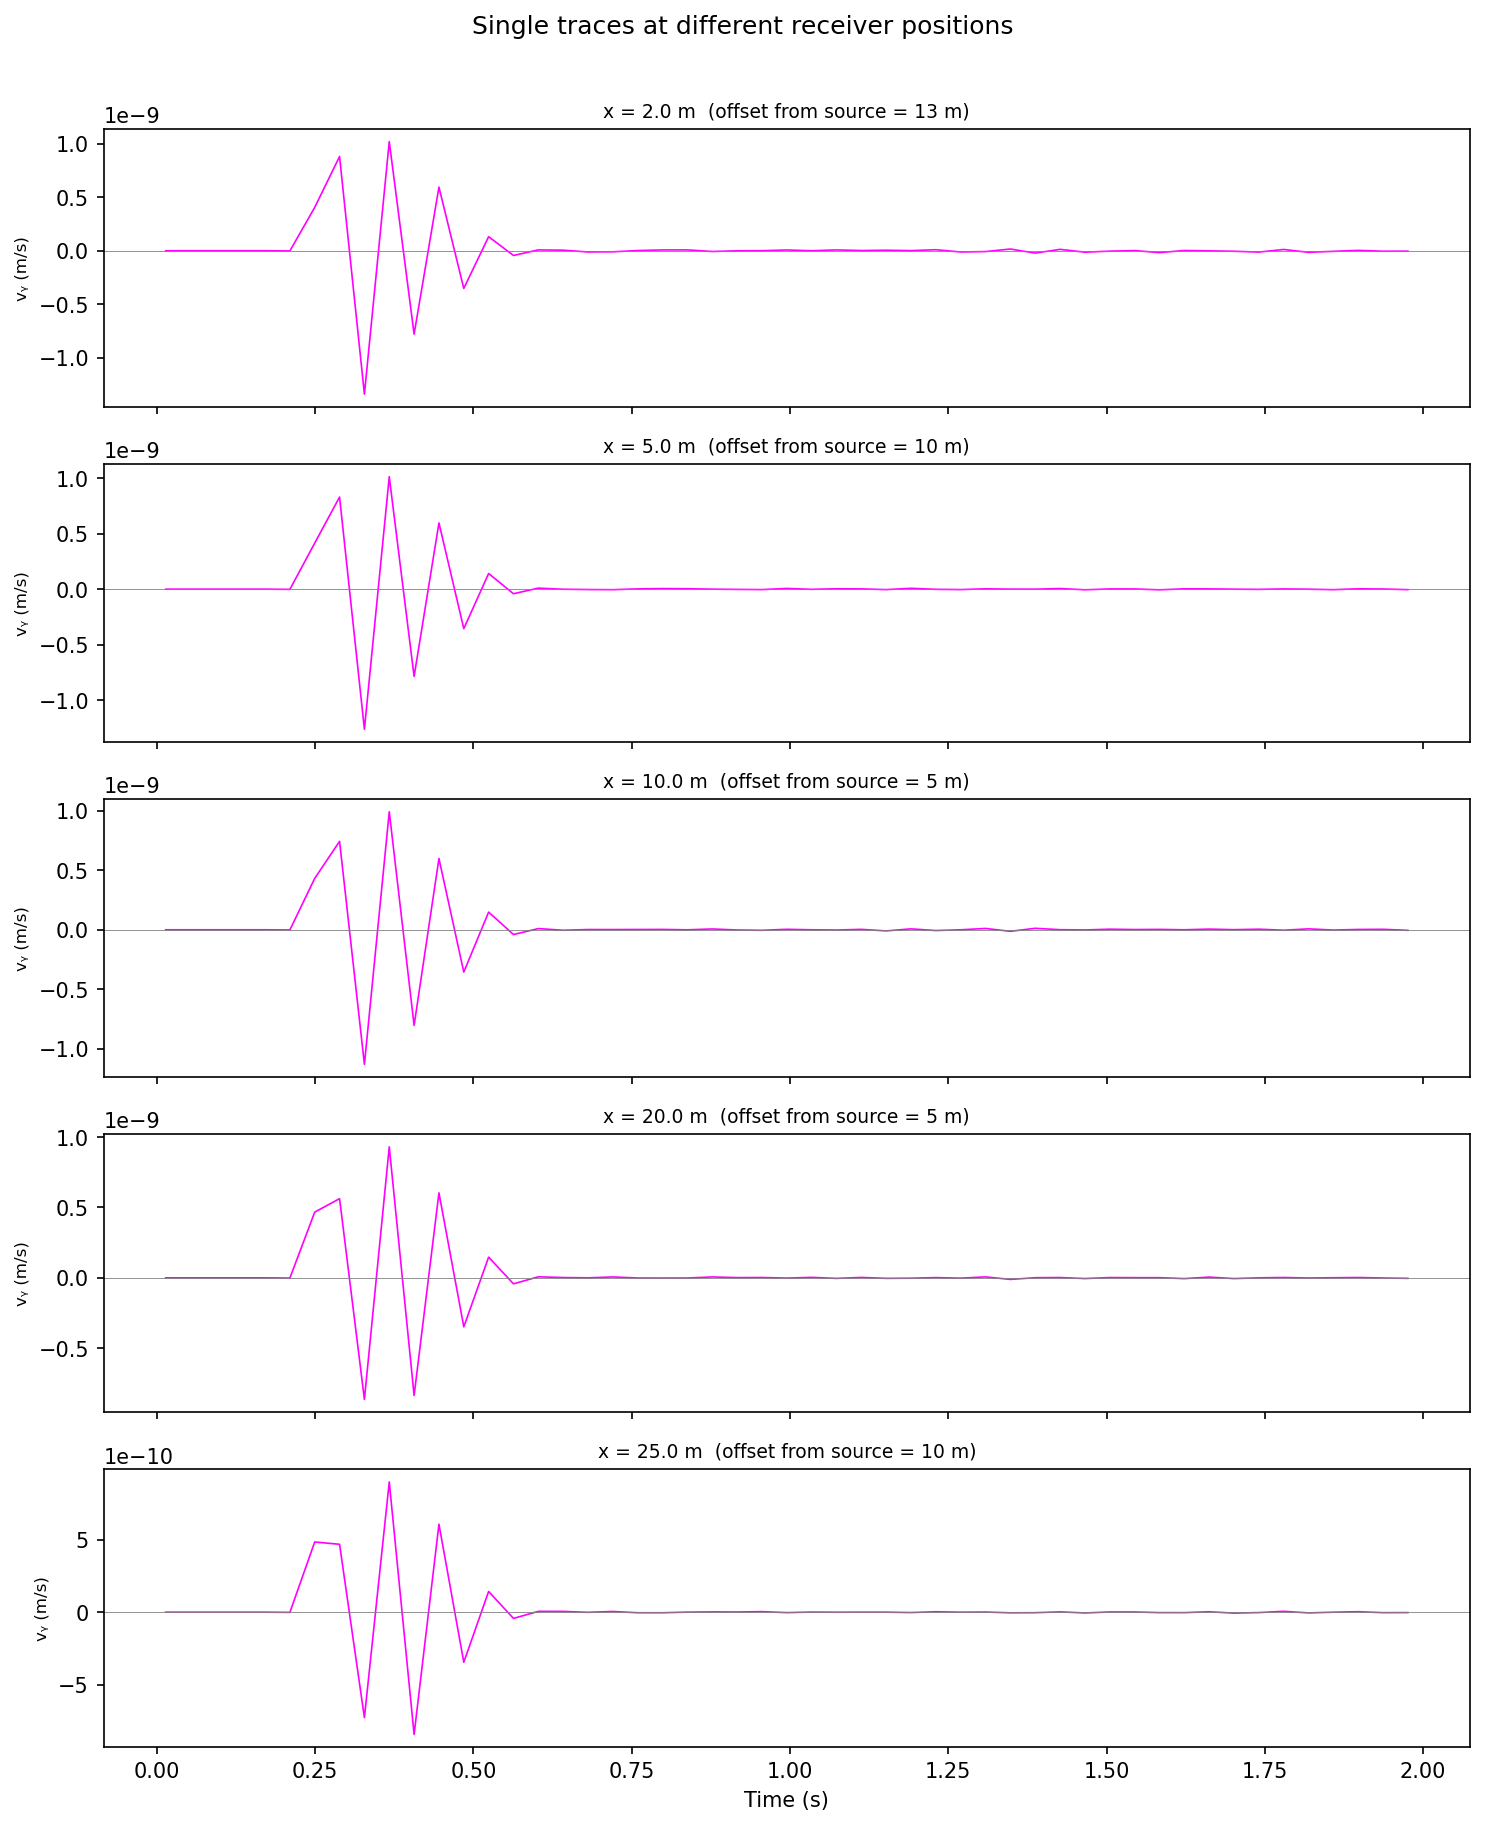

In [28]:
# # plotting seismogram for a single ppoint
# single_trace = sg_vy.sel(point=0.0, method="nearest")  # far-field receiver
# plt.plot(single_trace.t, single_trace.values)
# plt.xlabel("Time (s)")
# plt.ylabel("vᵧ (m/s)")
# plt.title("Far-field seismogram at x=0")
# plt.show()

# #  plotting frequency content 
# from numpy.fft import rfft, rfftfreq
# dt = float(single_trace.t.diff("t").mean())
# spectrum = np.abs(rfft(single_trace.values))
# freqs    = rfftfreq(len(single_trace), d=dt)
# plt.figure()
# plt.plot(freqs, spectrum)
# plt.xlabel("Frequency (Hz)")
# plt.xlim(0, 100)
# plt.title("Frequency spectrum of far-field signal")
# plt.show()

# try several receiver positions and compare
positions = [2.0, 5.0, 10.0, 20.0, 25.0]
fig, axes = plt.subplots(len(positions), 1, figsize=(10, 12), sharex=True)
for ax, x_recv in zip(axes, positions):
    trace = sg_vy.sel(point=x_recv, method="nearest")  # reuses strided sg_vy
    ax.plot(trace.t, trace.values, lw=0.8, color="magenta")
    ax.set_ylabel("vᵧ (m/s)", fontsize=8)
    ax.set_title(f"x = {x_recv} m  (offset from source = {abs(x_recv - 15):.0f} m)", fontsize=9)
    ax.axhline(0, color="gray", lw=0.4)
axes[-1].set_xlabel("Time (s)")
plt.suptitle("Single traces at different receiver positions", y=1.01)
plt.tight_layout()
plt.show()

Sampling frequency: 25.5 Hz
Nyquist frequency:  12.7 Hz


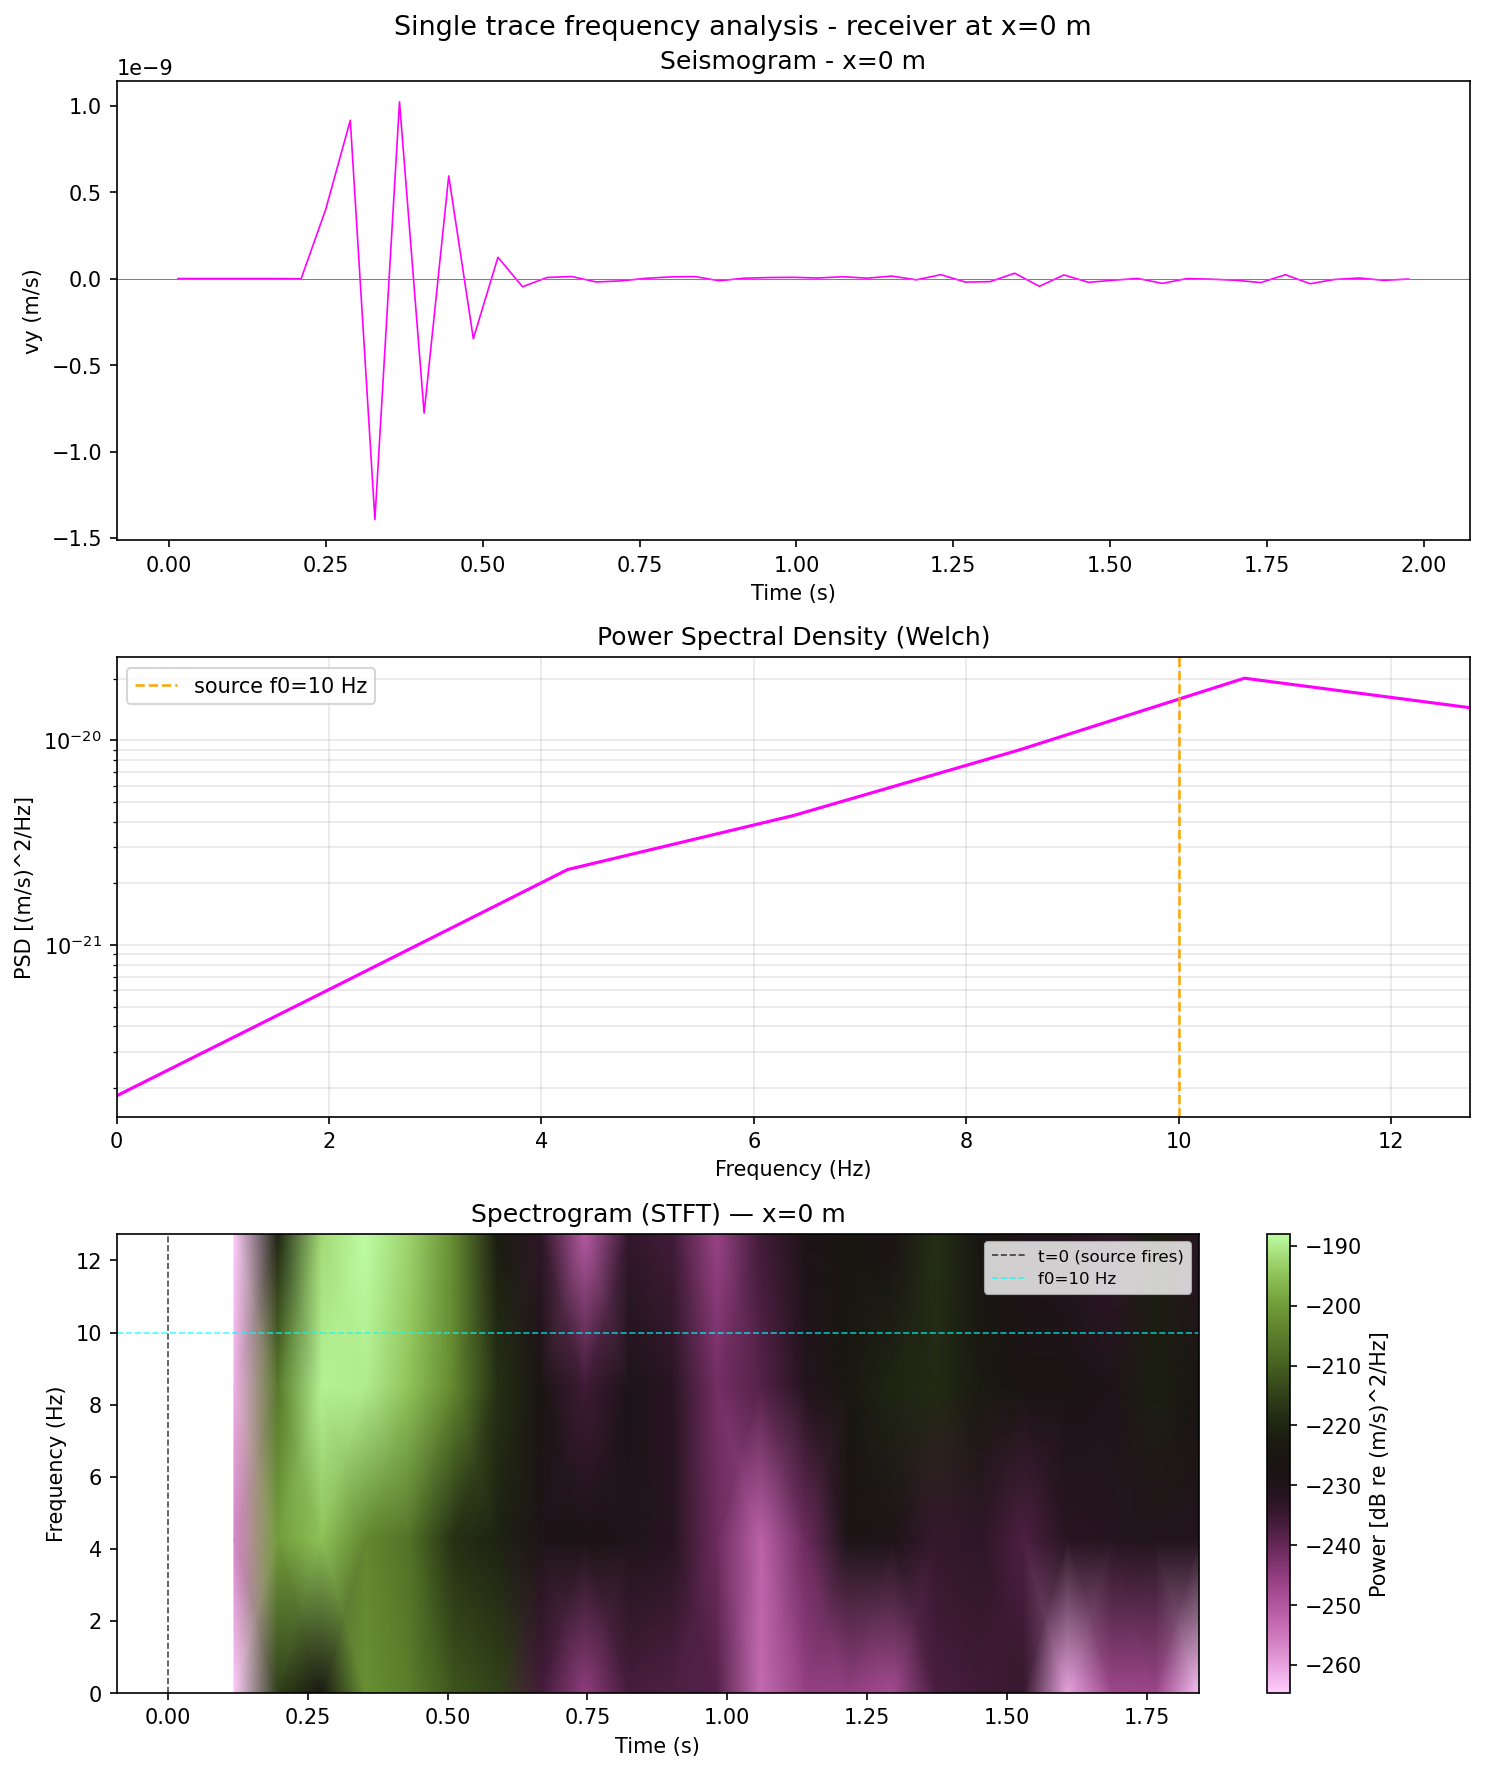

In [ ]:

# Extracting trace — picking far from source so source doesn't dominate
#  for Welch/STFT, dense time sampling matters. If the stride of 100
# gives too coarse a dt, reload vel_wo_layered with a smaller stride here.
trace = vel_sg.isel(c=1).sel(point=0.0, method="nearest").sel(t=slice(0, 2.0))
t_vals = trace.t.values
y_vals = trace.values

# dt and sampling frequency
dt = float(np.diff(t_vals).mean())
fs = 1.0 / dt
print(f"Sampling frequency: {fs:.1f} Hz")
print(f"Nyquist frequency:  {fs/2:.1f} Hz")

fig, axes = plt.subplots(3, 1, figsize=(10, 12))

# Raw seismogram
axes[0].plot(t_vals, y_vals, lw=0.8, color="magenta")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("vy (m/s)")
axes[0].set_title("Seismogram - x=0 m")
axes[0].axhline(0, color="gray", lw=0.5)

# Power Spectral Density (Welch method)
nperseg = min(1024, len(y_vals) // 4)
freqs_psd, psd = signal.welch(
    y_vals,
    fs=fs,
    nperseg=nperseg,
    noverlap=nperseg // 2,
    window="hann",      # reduces spectral leakage
    scaling="density",  # units: (m/s)^2/Hz
)
axes[1].semilogy(freqs_psd, psd, color="magenta")
axes[1].axvline(10, color="orange", lw=1.2, linestyle="--", label="source f0=10 Hz")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("PSD [(m/s)^2/Hz]")
axes[1].set_title("Power Spectral Density (Welch)")
axes[1].set_xlim(0, fs / 2)
axes[1].legend()
axes[1].grid(True, which="both", alpha=0.3)

# Spectrogram (STFT)
nperseg_stft = min(512, len(y_vals) // 8)
freqs_stft, t_stft, Sxx = signal.spectrogram(
    y_vals,
    fs=fs,
    nperseg=nperseg_stft,
    noverlap=nperseg_stft * 3 // 4,  # 75% overlap — smooth time axis
    window="hann",
    scaling="density",
)
Sxx_log = 10 * np.log10(Sxx + 1e-40)  # dB, small floor to avoid log(0)
im = axes[2].pcolormesh(
    t_stft, freqs_stft, Sxx_log,
    shading="gouraud",
    cmap="vanimo",
)
axes[2].axvline(0,  color="black", lw=0.8, linestyle="--", alpha=0.7, label="t=0 (source fires)")
axes[2].axhline(10, color="cyan",  lw=0.8, linestyle="--", alpha=0.7, label="f0=10 Hz")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Frequency (Hz)")
axes[2].set_title("Spectrogram (STFT) — x=0 m")
axes[2].set_ylim(0, min(100, fs / 2))
axes[2].legend(loc="upper right", fontsize=8)
fig.colorbar(im, ax=axes[2], label="Power [dB re (m/s)^2/Hz]")
plt.suptitle("Single trace frequency analysis - receiver at x=0 m", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Plotting the same but with a bandpass filter
# Bandpass-enabled single-trace + PSD + spectrogram
trace = vel_sg.isel(c=1).sel(point=0.0, method="nearest").sel(t=slice(0, 2.0))
t_vals = trace.t.values
y_raw = trace.values

# sampling properties
dt = float(np.diff(t_vals).mean())
fs = 1.0 / dt
print(f"Sampling frequency: {fs:.1f} Hz")
print(f"Nyquist frequency:  {fs/2:.1f} Hz")

def bandpass(trace_in, fs, f_low=5.0, f_high=20.0, order=4):
    """Zero-phase Butterworth bandpass filter."""
    nyq = fs / 2.0
    f_low = max(f_low, 1e-6)
    f_high = min(f_high, 0.999 * nyq)
    if not (0 < f_low < f_high < nyq):
        raise ValueError(f"Invalid bandpass: f_low={f_low}, f_high={f_high}, Nyquist={nyq}")
    sos = signal.butter(order, [f_low / nyq, f_high / nyq], btype="band", output="sos")
    return signal.sosfiltfilt(sos, trace_in)

# choose pass-band here
f_low, f_high = 5.0, 20.0
y_filt = bandpass(y_raw, fs=fs, f_low=f_low, f_high=f_high, order=4)

fig, axes = plt.subplots(3, 1, figsize=(10, 12))

# 1) time series
axes[0].plot(t_vals, y_raw, lw=0.8, color="gray", alpha=0.7, label="Raw")
axes[0].plot(t_vals, y_filt, lw=1.0, color="magenta", label=f"Bandpassed ({f_low}-{f_high} Hz)")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("vy (m/s)")
axes[0].set_title("Seismogram — x=0 m")
axes[0].axhline(0, color="gray", lw=0.5)
axes[0].legend()

# 2) PSD
nperseg = min(1024, len(y_raw) // 4)
freqs_psd_raw, psd_raw = signal.welch(
    y_raw,
    fs=fs,
    nperseg=nperseg,
    noverlap=nperseg // 2,
    window="hann",
    scaling="density",
)
freqs_psd_filt, psd_filt = signal.welch(
    y_filt,
    fs=fs,
    nperseg=nperseg,
    noverlap=nperseg // 2,
    window="hann",
    scaling="density",
)

axes[1].semilogy(freqs_psd_raw, psd_raw, color="gray", alpha=0.7, label="Raw")
axes[1].semilogy(freqs_psd_filt, psd_filt, color="magenta", label=f"Bandpassed ({f_low}-{f_high} Hz)")
axes[1].axvline(10, color="orange", lw=1.2, linestyle="--", label="source f0=10 Hz")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("PSD [(m/s)^2/Hz]")
axes[1].set_title("Power Spectral Density (Welch)")
axes[1].set_xlim(0, fs / 2)
axes[1].legend()
axes[1].grid(True, which="both", alpha=0.3)

# 3) STFT spectrogram of filtered signal
nperseg_stft = min(512, len(y_filt) // 8)
freqs_stft, t_stft, Sxx = signal.spectrogram(
    y_filt,
    fs=fs,
    nperseg=nperseg_stft,
    noverlap=nperseg_stft * 3 // 4,
    window="hann",
    scaling="density",
)

Sxx_log = 10 * np.log10(Sxx + 1e-40)
im = axes[2].pcolormesh(t_stft, freqs_stft, Sxx_log, shading="gouraud", cmap="vanimo")
axes[2].axvline(0, color="black", lw=0.8, linestyle="--", alpha=0.7, label="t=0 (source fires)")
axes[2].axhline(10, color="cyan", lw=0.8, linestyle="--", alpha=0.7, label="f0=10 Hz")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Frequency (Hz)")
axes[2].set_title(f"Spectrogram (STFT) — bandpassed {f_low}-{f_high} Hz, x=0 m")
axes[2].set_ylim(0, min(100, fs / 2))
axes[2].legend(loc="upper right", fontsize=8)
fig.colorbar(im, ax=axes[2], label="Power [dB re (m/s)^2/Hz]")

plt.suptitle("Single trace frequency analysis — receiver at x=0 m", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:

# Wiggle plot form shotgather
sg = vel_sg.isel(c=1)  # component to plot (vx/vy)
rec_dim = [d for d in sg.dims if d != "t"][0]
sg = sg.assign_coords({rec_dim: x_line}).rename({rec_dim: "x"})
sg_tx = sg.transpose("t", "x")  # [time, distance]

t = sg_tx["t"].values
x = sg_tx["x"].values
A = sg_tx.values  # shape: [nt, nx]

# Plot settings
trace_step = 30  # plotting  every Nth receiver 
wiggle_scale = 0.7 * np.median(np.diff(x)) * trace_step

fig, ax = plt.subplots(figsize=(14, 8))

for i in range(0, len(x), trace_step):
    tr = A[:, i].copy()
    x0 = x[i]

 # normalization per trace by its own maximum s that wiggles can be seen 
    tr_max = np.max(np.abs(tr))
    if tr_max < 1e-20:      # skip dead traces
        continue
    tr /= tr_max

    # optional: clip wild amplitudes at early time
    #tr = np.clip(tr, -1, 1)

    xwig = x0 + wiggle_scale * tr

    ax.plot(xwig, t, color="black", lw=0.5)
    ax.fill_betweenx(t, x0, xwig,
                     where=(tr > 0),
                     color="black", alpha=0.7, linewidth=0)

ax.invert_yaxis()
ax.set_xlim(x[0] - wiggle_scale, x[-1] + wiggle_scale)
ax.set_xlabel("Distance along interface (m)")
ax.set_ylabel("Time (s)")
ax.set_title("Wiggle shot gather — y=2.0 m")
plt.tight_layout()
plt.show()


In [ ]:
def bandpass(trace, fs, f_low=1.0, f_high=30.0, order=4):
    """Zero-phase Butterworth bandpass filter."""
    nyq = fs / 2
    sos = signal.butter(
        order,
        [f_low / nyq, f_high / nyq],
        btype="band",
        output="sos"
    )
    return signal.sosfiltfilt(sos, trace)  # sosfiltfilt = zero phase, no time shift

# compute sampling frequency from time axis
dt = float(np.diff(t).mean())
fs = 1.0 / dt

trace_step   = 30
wiggle_scale = 0.7 * np.median(np.diff(x)) * trace_step

fig, ax = plt.subplots(figsize=(14, 8))

for i in range(0, len(x), trace_step):
    tr = A[:, i].copy()

   # bandpass filter: filters out frequencies above and below a certain frequency
   # f_low: klow frequency threshold 
   # f_high: high frequency threshold 
    tr = bandpass(tr, fs, f_low=5.0, f_high=20.0, order=4)

    # per-trace normalisation
    tr_max = np.max(np.abs(tr))
    if tr_max < 1e-20:
        continue
    tr /= tr_max
    tr  = np.clip(tr, -1, 1)

    x0   = x[i]
    xwig = x0 + wiggle_scale * tr

    ax.plot(xwig, t, color="black", lw=0.5)
    ax.fill_betweenx(t, x0, xwig,
                     where=(tr > 0),
                     color="black", alpha=0.7, linewidth=0)

ax.invert_yaxis()
ax.set_xlim(x[0] - wiggle_scale, x[-1] + wiggle_scale) # automatically adjust xlim to fit wigglkes
ax.set_xlabel("Distance along interface (m)")
ax.set_ylabel("Time (s)")
ax.set_title(f"Wiggle shot gather - y=2.0 m  [bandpass {5}-{20} Hz]")
plt.tight_layout()
plt.show()

In [ ]:
# Plotting code for displacement field
out_2d_layered = p.simulations.get_simulation_output_directory("sim_2d_layered", "event_wavefield_output")

# Memory-safe read: load every Nth stored time step instead of the full volume
time_step_stride = 100
dis_wo_layered = wavefield_output.WavefieldOutput.from_file(
    pathlib.Path(
        out_2d_layered,
        "volume_data_output.h5",
    ),
    "displacement",
    "volume",
    time_steps=slice(0, None, time_step_stride),
)

# Converting to an xarray
dis_2d_layered = wavefield_output.wavefield_output_to_xarray(
    dis_wo_layered,
    points=[np.linspace(0, 30, 101), np.linspace(0, 3, 101)],
)

# Plotting displacement output
fig, ax = plt.subplots()
plot_time_seconds = 0.8
dis_2d_layered.sel(t=plot_time_seconds, method="nearest").isel(c=0).T.plot(
    shading="gouraud",
    infer_intervals=False,
)
ax.set_ylim(0,3)
ax.set_xlim(0,30)
ax.invert_yaxis()
ax.set_ylabel("Depth (m)")
ax.set_xlabel("Distance (m)")
plt.show()

In [ ]:
# Animation code

plt.rcParams["animation.html"] = "jshtml"
plt.rcParams["figure.dpi"] = 150
plt.ioff()

# Getting wavefield output like above (memory-safe decimation in time)
out_2d_layered = p.simulations.get_simulation_output_directory(
    "sim_2d_layered", "event_wavefield_output"
)

time_step_stride = 100
dis_wo_layered = wavefield_output.WavefieldOutput.from_file(
    pathlib.Path(out_2d_layered, "volume_data_output.h5"),
    "displacement",
    "volume",
    time_steps=slice(0, None, time_step_stride),
)
dis_2d_layered = wavefield_output.wavefield_output_to_xarray(
    dis_wo_layered,
    points=[
        np.linspace(0, 30, 101),  # width (m)
        np.linspace(0, 3, 101),   # height (m)
    ],
)

# Setting up animation
fig, ax = plt.subplots()

def animate(t):
    for coll in ax.collections:
        coll.remove()

    dis_2d_layered.isel(c=1, t=t).T.plot(
        ax=ax,
        shading="gouraud",
        infer_intervals=False,
        add_colorbar=False,
    )

    # Force axis limits
    ax.set_ylim(0,3)
    ax.set_xlim(0,30)
    ax.invert_yaxis()
    ax.set_ylabel("Depth (m)")
    ax.set_xlabel("Distance (m)")

    # Kill autoscaling
    ax.set_autoscale_on(False)

    ax.set_title(f"Displacement field (t = {t})")

# Creating animation
ani_layered = animation.FuncAnimation(
    fig,
    animate,
    frames=dis_2d_layered.sizes["t"],
    interval=100  # change interval to a higher value for slower animation
)

ani_layered

In [ ]:
y_surface = 3 * 1 / 3
x_line = np.linspace(0.0, 30.0, 1001)
y_line = np.full_like(x_line, y_surface)

dis_sg = wavefield_output.wavefield_output_to_xarray(
    dis_wo_layered,
    points=np.column_stack((x_line, y_line)),
)
# vy is vertical particle velocity — most sensitive to P-wave arrivals
sg_vy = dis_sg.isel(c=1).sel(t=slice(0, 2.0))
sg_vy["point"] = x_line  # distance in m along x 

sg_vy.plot(
    x="point",
    y="t",
    shading="gouraud",
    infer_intervals=False,
    cbar_kwargs= {"label": "Vertical particle displacement (m)", "shrink": 0.8,},
    yincrease=False,
    robust=True,# this clips colorscale so that the source doesnt dominate the plot and the other waves can be seen 
)
plt.xlabel("x (m)")
plt.ylabel("Time (s)")
plt.axvline(x=15, color="white", lw=0.8, linestyle="--", label="source x=15") # add vertical line to source location for easier interpretation (can also be commented)
plt.title("Seismic waterfall plot below source location at 1m depth in snow")
plt.show()

In [ ]:

# Extracting trace, picking trace far away from source so that source doesnt dominate
trace = vel_sg.isel(c=1).sel(point=0.0, method="nearest").sel(t=slice(0, 2.0))
t_vals = trace.t.values
y_vals = trace.values

# dt and sampling frequency
dt = float(np.diff(t_vals).mean())
fs = 1.0 / dt
print(f"Sampling frequency: {fs:.1f} Hz")
print(f"Nyquist frequency:  {fs/2:.1f} Hz")

fig, axes = plt.subplots(3, 1, figsize=(10, 12))

# PLotting raw seismogram 
axes[0].plot(t_vals, y_vals, lw=0.8, color="magenta")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("displacement (m)")
axes[0].set_title("Seismogram — x=0 m")
axes[0].axhline(0, color="gray", lw=0.5) 

#  Power Spectral Density (Welch method)
# Welch averages many overlapping windows 
# nperseg controls frequency resolution: longer = finer freq bins
nperseg = min(1024, len(y_vals) // 4)

freqs_psd, psd = signal.welch(
    y_vals,
    fs=fs,
    nperseg=nperseg,
    noverlap=nperseg // 2,
    window="hann",           # hann window reduces spectral leakage
    scaling="density",       # units ms^2/HZ
)

axes[1].semilogy(freqs_psd, psd, color="magenta")
axes[1].axvline(10, color="orange", lw=1.2, linestyle="--", label="source f0=10 Hz")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("PSD [(m/s)^2/Hz]")
axes[1].set_title("Power Spectral Density (Welch)")
axes[1].set_xlim(0, fs / 2)
axes[1].legend()
axes[1].grid(True, which="both", alpha=0.3)

# spectrogram 
# nperseg_stft controls the time/frequency resolution tradeoff:
# longer window --< finer frequency resolution, coarser time resolution
#  shorter window --> finer time resolution, coarser frequency resolution
# aim fabput ~3-5 cycles of  lowest frequency of interest per window --> CHANGE THIS DEPENDING ON WHICH FREQUENCY 
nperseg_stft = min(512, len(y_vals) // 8)

freqs_stft, t_stft, Sxx = signal.spectrogram(
    y_vals,
    fs=fs,
    nperseg=nperseg_stft,
    noverlap=nperseg_stft * 3 // 4,   # 75% overlap — smooth time axis
    window="hann",
    scaling="density",
)

#log scale for amplitude — seismic signals span many orders of magnitude
Sxx_log = 10 * np.log10(Sxx + 1e-40)   # dB, small floor to avoid log(0)

im = axes[2].pcolormesh(
    t_stft, freqs_stft, Sxx_log,
    shading="gouraud",
    cmap="vanimo",
)
axes[2].axvline(0,  color="black", lw=0.8, linestyle="--", alpha=0.7, label="t=0 (source fires)")
axes[2].axhline(10, color="cyan",  lw=0.8, linestyle="--", alpha=0.7, label="f0=10 Hz")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Frequency (Hz)")
axes[2].set_title("Spectrogram (STFT) — x=0 m")
axes[2].set_ylim(0, min(100, fs / 2))   # cap at 100 Hz or Nyquist
axes[2].legend(loc="upper right", fontsize=8)
fig.colorbar(im, ax=axes[2], label="Power [dB re (m/s)^2/Hz]")

plt.suptitle("Single trace frequency analysis — receiver at x=0 m", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:

# Wiggle plot form shotgather
sg = dis_sg.isel(c=1)  # component to plot (vx/vy)
rec_dim = [d for d in sg.dims if d != "t"][0]
sg = sg.assign_coords({rec_dim: x_line}).rename({rec_dim: "x"})
sg_tx = sg.transpose("t", "x")  # [time, distance]

t = sg_tx["t"].values
x = sg_tx["x"].values
A = sg_tx.values  # shape: [nt, nx]

# Plot settings
trace_step = 30  # plotting  every Nth receiver 
wiggle_scale = 0.7 * np.median(np.diff(x)) * trace_step

fig, ax = plt.subplots(figsize=(14, 8))

for i in range(0, len(x), trace_step):
    tr = A[:, i].copy()
    x0 = x[i]

 # normalization per trace by its own maximum s that wiggles can be seen 
    tr_max = np.max(np.abs(tr))
    if tr_max < 1e-20:      # skip dead traces
        continue
    tr /= tr_max

    # optional: clip wild amplitudes at early time
    #tr = np.clip(tr, -1, 1)

    xwig = x0 + wiggle_scale * tr

    ax.plot(xwig, t, color="black", lw=0.5)
    ax.fill_betweenx(t, x0, xwig,
                     where=(tr > 0),
                     color="black", alpha=0.7, linewidth=0)

ax.invert_yaxis()
ax.set_xlim(x[0] - wiggle_scale, x[-1] + wiggle_scale)
ax.set_xlabel("Distance along interface (m)")
ax.set_ylabel("Time (s)")
ax.set_title("Wiggle shot gather — y=2.0 m")
plt.tight_layout()
plt.show()
